In [3]:
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import inaugural, stopwords
from nltk.probability import FreqDist, ConditionalFreqDist
from wordcloud import WordCloud

# Run these only if the datasets are not already installed
# nltk.download("inaugural")
# nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

print("Available speeches:")
print(inaugural.fileids())

Available speeches:
['1789-Washington.txt', '1793-Washington.txt', '1797-Adams.txt', '1801-Jefferson.txt', '1805-Jefferson.txt', '1809-Madison.txt', '1813-Madison.txt', '1817-Monroe.txt', '1821-Monroe.txt', '1825-Adams.txt', '1829-Jackson.txt', '1833-Jackson.txt', '1837-VanBuren.txt', '1841-Harrison.txt', '1845-Polk.txt', '1849-Taylor.txt', '1853-Pierce.txt', '1857-Buchanan.txt', '1861-Lincoln.txt', '1865-Lincoln.txt', '1869-Grant.txt', '1873-Grant.txt', '1877-Hayes.txt', '1881-Garfield.txt', '1885-Cleveland.txt', '1889-Harrison.txt', '1893-Cleveland.txt', '1897-McKinley.txt', '1901-McKinley.txt', '1905-Roosevelt.txt', '1909-Taft.txt', '1913-Wilson.txt', '1917-Wilson.txt', '1921-Harding.txt', '1925-Coolidge.txt', '1929-Hoover.txt', '1933-Roosevelt.txt', '1937-Roosevelt.txt', '1941-Roosevelt.txt', '1945-Roosevelt.txt', '1949-Truman.txt', '1953-Eisenhower.txt', '1957-Eisenhower.txt', '1961-Kennedy.txt', '1965-Johnson.txt', '1969-Nixon.txt', '1973-Nixon.txt', '1977-Carter.txt', '1981-Reag

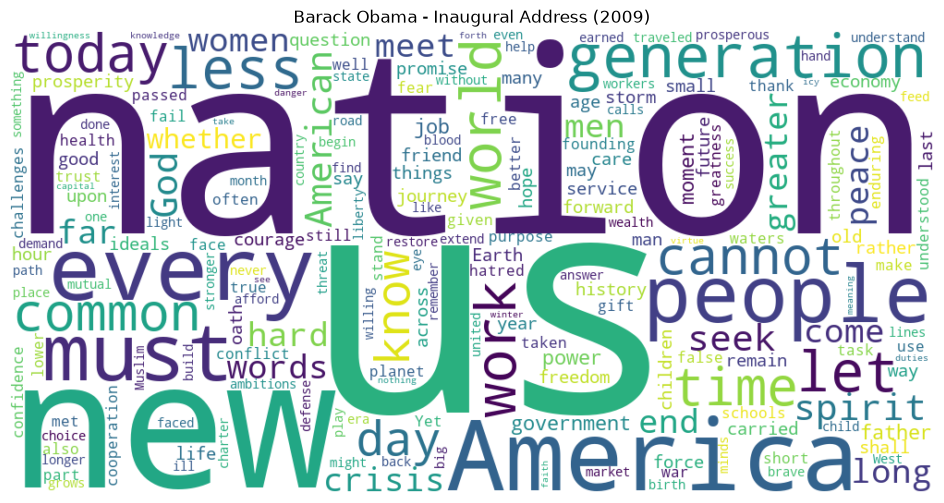

In [5]:
# Load Obama's 2009 inaugural address
text = inaugural.raw("2009-Obama.txt")

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=stop_words
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Barack Obama - Inaugural Address (2009)")
plt.show()

Top 20 most frequent words:
us              23
nation          12
new             11
america         10
every           8
must            8
people          7
less            7
world           7
let             7
today           6
time            6
work            6
cannot          6
common          6
generation      5
day             5
know            5
spirit          5
god             5


<Axes: title={'center': 'Top 20 Words - Obama 2009'}, xlabel='Samples', ylabel='Counts'>

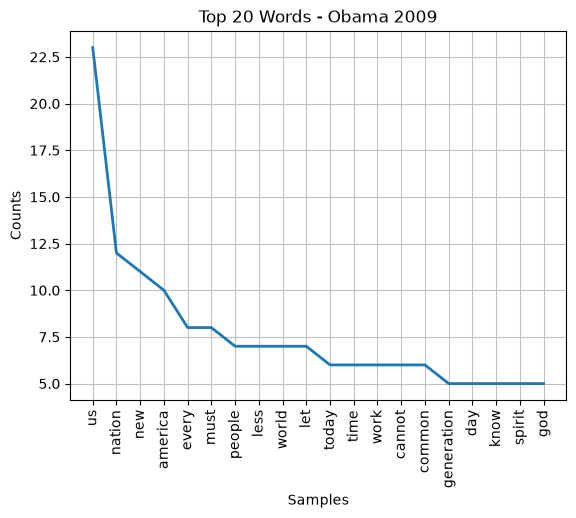

In [7]:
words = inaugural.words("2009-Obama.txt")

filtered_words = [
    word.lower()
    for word in words
    if word.isalpha() and word.lower() not in stop_words
]

fd = FreqDist(filtered_words)

print("Top 20 most frequent words:")
for word, freq in fd.most_common(20):
    print(f"{word:15} {freq}")

fd.plot(20, title="Top 20 Words - Obama 2009")

In [9]:
high_freq = fd.most_common(100)

longest_high_freq = sorted(
    high_freq,
    key=lambda x: len(x[0]),
    reverse=True
)

print(f"{'Word':20} {'Length':8} {'Frequency'}")
print("-" * 40)

for word, freq in longest_high_freq[:20]:
    print(f"{word:20} {len(word):8} {freq}")

Word                 Length   Frequency
----------------------------------------
generations                11 3
cooperation                11 2
generation                 10 5
prosperity                 10 3
government                 10 3
throughout                 10 2
understood                 10 2
confidence                 10 2
americans                   9 3
question                    8 3
children                    8 3
founding                    8 2
america                     7 10
greater                     7 4
whether                     7 4
carried                     7 3
economy                     7 3
history                     7 3
forward                     7 3
journey                     7 3


In [11]:
words = inaugural.words("1789-Washington.txt")

filtered_words = [
    word.lower()
    for word in words
    if word.isalpha() and word.lower() not in stop_words
]

fd_washington = FreqDist(filtered_words)

# Words occurring at least 3 times
high_freq_words = [
    (word, freq)
    for word, freq in fd_washington.items()
    if freq >= 3
]

# Longest first; frequency breaks ties
result = sorted(
    high_freq_words,
    key=lambda x: (len(x[0]), x[1]),
    reverse=True
)

print(f"{'Word':20} {'Length':8} {'Frequency'}")
print("-" * 40)

for word, freq in result:
    print(f"{word:20} {len(word):8} {freq}")

Word                 Length   Frequency
----------------------------------------
government                 10 8
happiness                   9 3
citizens                    8 5
measures                    8 3
present                     7 5
country                     7 5
public                      6 6
people                      6 4
united                      6 4
fellow                      6 3
nature                      6 3
every                       5 9
ought                       5 4
since                       5 4
could                       5 3
great                       5 3
shall                       5 3
duty                        4 4
hand                        4 3
good                        4 3
less                        4 3
must                        4 3
may                         3 6
one                         3 4
far                         3 3


              freedom government     nation     people    america 
Washington          0          8          2          4          0 
   Lincoln          0          1          3          0          0 
 Roosevelt          0          3          6          8          0 
   Kennedy          4          0          2          1          2 
     Obama          3          3         12          7         10 


<Axes: title={'center': 'Word Usage Across Presidents'}, xlabel='Samples', ylabel='Counts'>

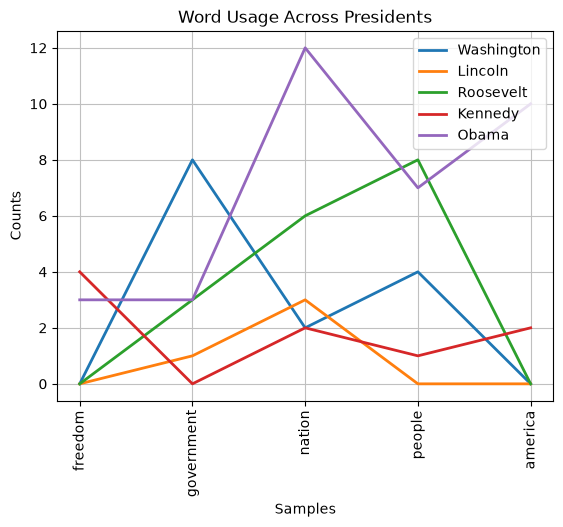

In [13]:
from nltk.probability import ConditionalFreqDist

speeches = {
    "Washington": "1789-Washington.txt",
    "Lincoln": "1865-Lincoln.txt",
    "Roosevelt": "1933-Roosevelt.txt",
    "Kennedy": "1961-Kennedy.txt",
    "Obama": "2009-Obama.txt"
}

cfd = ConditionalFreqDist(
    (president, word.lower())
    for president, fileid in speeches.items()
    for word in inaugural.words(fileid)
    if word.isalpha()
)

target_words = [
    "freedom",
    "government",
    "nation",
    "people",
    "america"
]

cfd.tabulate(
    conditions=speeches.keys(),
    samples=target_words
)

cfd.plot(
    conditions=speeches.keys(),
    samples=target_words,
    title="Word Usage Across Presidents"
)

In [15]:
results = []

for fileid in inaugural.fileids():

    words = [
        word.lower()
        for word in inaugural.words(fileid)
        if word.isalpha() and word.lower() not in stop_words
    ]

    # Define high-sounding words as words with 10+ letters
    high_sounding = [
        word for word in words
        if len(word) >= 10
    ]

    percentage = (
        len(high_sounding) / len(words) * 100
        if words else 0
    )

    results.append(
        (fileid, len(high_sounding), percentage)
    )

# Sort by percentage
results.sort(
    key=lambda x: x[2],
    reverse=True
)

print(f"{'Speech':30} {'Count':8} {'Percentage'}")
print("-" * 55)

for fileid, count, percentage in results:
    print(
        f"{fileid:30} "
        f"{count:8} "
        f"{percentage:8.2f}%"
    )

# President/speech with highest percentage
winner = results[0]

print("\nHighest use of high-sounding words:")
print("Speech:", winner[0])
print("Percentage:", round(winner[2], 2), "%")

Speech                         Count    Percentage
-------------------------------------------------------
1825-Adams.txt                      305    22.46%
1789-Washington.txt                 144    22.22%
1809-Madison.txt                    113    21.65%
1929-Hoover.txt                     364    21.25%
1829-Jackson.txt                    111    21.14%
1849-Taylor.txt                     110    21.03%
1893-Cleveland.txt                  205    20.77%
1833-Jackson.txt                    109    20.00%
1845-Polk.txt                       453    19.94%
1885-Cleveland.txt                  159    19.73%
1853-Pierce.txt                     310    19.68%
1901-McKinley.txt                   207    19.53%
1797-Adams.txt                      202    18.95%
1837-VanBuren.txt                   357    18.91%
1921-Harding.txt                    318    18.51%
1841-Harrison.txt                   700    18.36%
1909-Taft.txt                       462    17.94%
1881-Garfield.txt                   255    

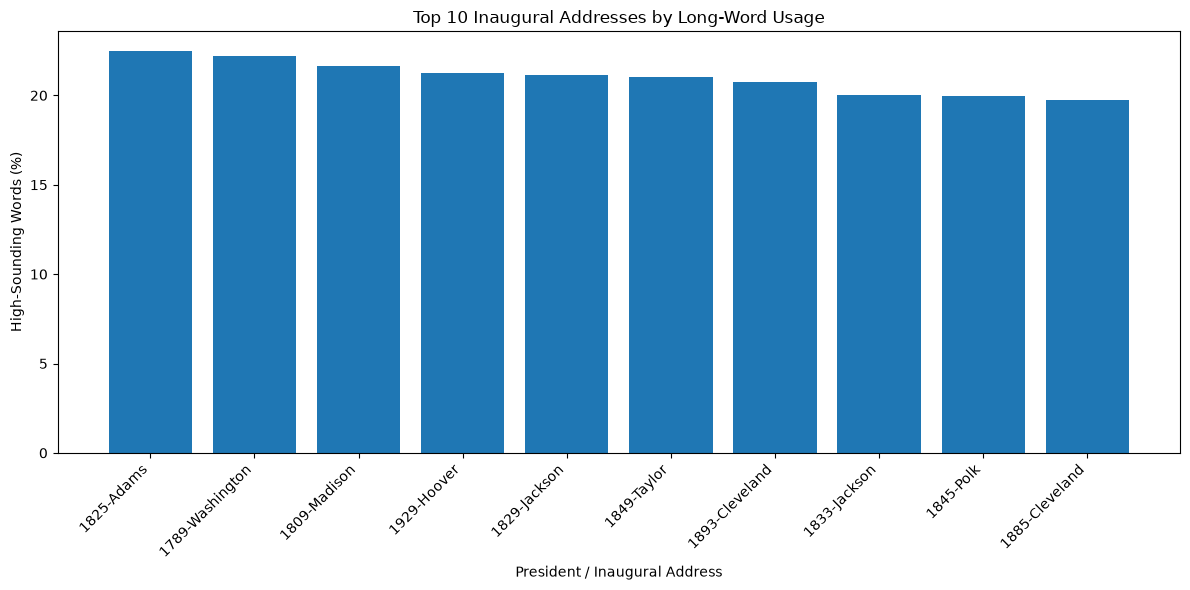

In [17]:
top10 = results[:10]

speech_names = [
    fileid.replace(".txt", "")
    for fileid, _, _ in top10
]

percentages = [
    percentage
    for _, _, percentage in top10
]

plt.figure(figsize=(12, 6))

plt.bar(speech_names, percentages)

plt.xlabel("President / Inaugural Address")
plt.ylabel("High-Sounding Words (%)")
plt.title("Top 10 Inaugural Addresses by Long-Word Usage")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()